# Unsupervised Learning.
 

### Mean.
 - The mean is the average value of data points.
   - For example, if the data points are: (2,3), (4,5), (6,7)
   - Mean of x-values: 2+4+6/3=4
   - Mean of y-values:3+5+7/3=5
   - So the mean point is:(4,5)

### Cnetroid.
  - A centroid is the center of a cluster and is calculated as the mean of all points belonging to that cluster.
  - In the K-Means clustering algorithm:
  - Randomly choose centroids.
  - Assign data points to the nearest centroid.
  - Recalculate the centroid as the mean of all points in the cluster.
  - Repeat until centroids stop changing
  - Example
  - Cluster points:(1,2), (2,3), (3,4)
  - Centroid:(1+2+3/3,2+3+4/3)=(2,3)

  - So:
      - Mean = Average of a set of values.
      - Centroid = Mean position of all points in a cluster.
      - In K-Means clustering, the centroid is simply the mean of the cluster points.

### Euclidian Distance.
   - Euclidean Distance is the straight-line distance between two points in space. It is the most commonly used distance measure in K-Means clustering and other machine learning algorithms.

   - d=√(x2​−x1​)^2+(y2​−y1​)^2
​

In [9]:
import pandas as pd 

### Variance&Spread.
    - Spread = A general idea of how scattered the data is.
    - Variance = A mathematical measure that quantifies that spread.

##### Spread.
- Spread refers to how far apart the data values are.
- Low spread: Values are close to each other.
      - Example: 48, 49, 50, 51, 52
- High spread: Values are more dispersed.
      - Example: 10, 30, 50, 70, 90

#### Variance.
- Variance is a numerical measure of spread. It tells you, on average, how far the data points are from the mean after squaring the differences.

      - Low variance: Data points are close to the mean.
      - High variance: Data points are far from the mean.

# Unsupervised Learning.
- Unsupervised learning is a type of machine learning where the model is trained on data without labeled outputs.   Unlike supervised learning, there is no target variable; the algorithm tries to discover hidden patterns or structures within the data

  ### Clustering.
    - Clustering is an unsupervised learning technique used to group similar data points together based on their    patterns or characteristics.

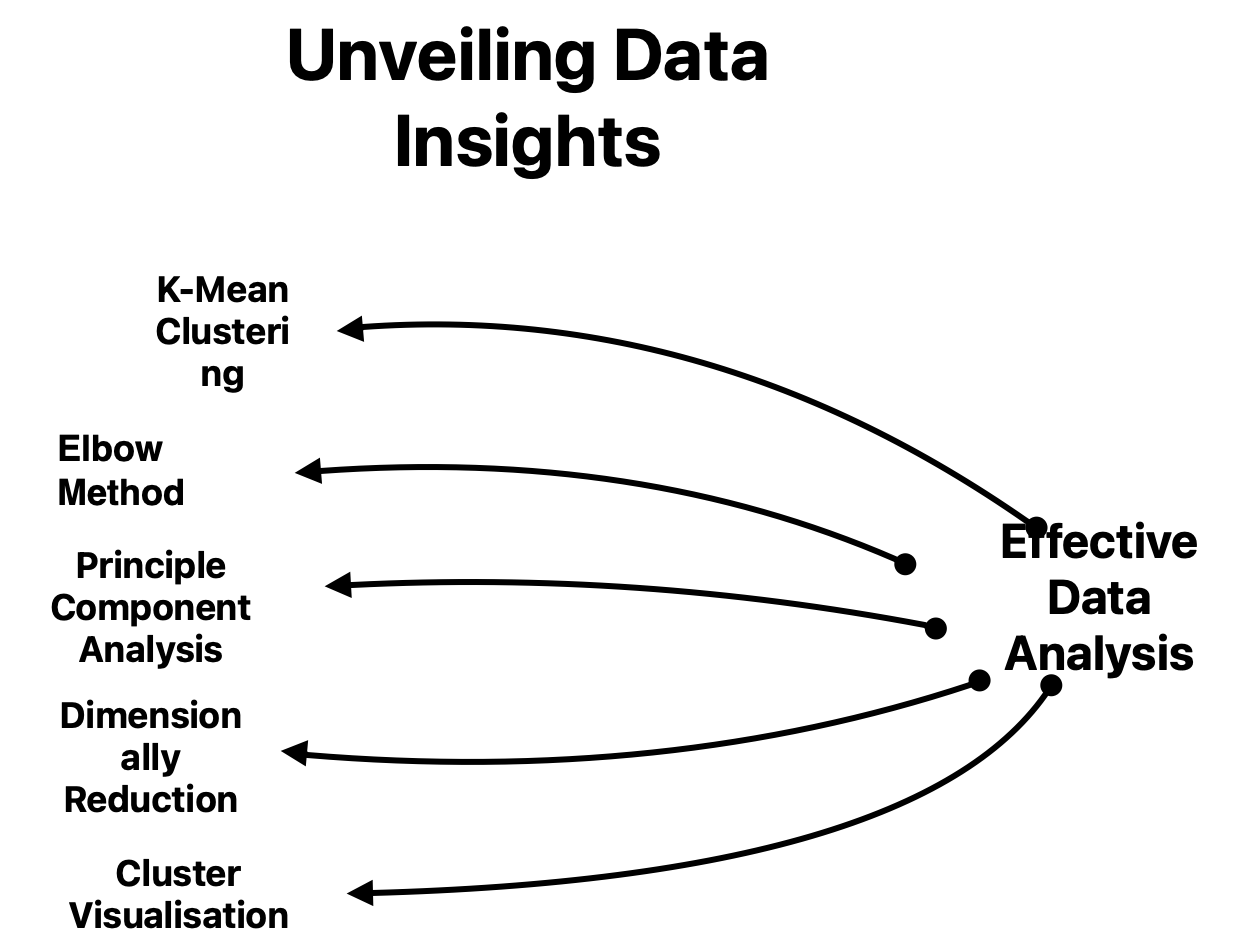

### K-Mean Clustering.
   - K-Means Clustering is an unsupervised machine learning algorithm that groups similar data points into K clusters based on their similarity. The algorithm tries to make points within the same cluster as similar as possible while keeping different clusters as distinct as possible.
    

#### 5 Steps in K-Mean Clustering.
    - step1.
        - Choose the number of clusters (K)
        - Decide how many clusters you want to create. Example k=2, k=3.

    - step2.
        - Select K random centroids
         
    - Step3.
        - Assign points to the nearest centroid
        
    - Step4.
        - Calculate new centroids (means)
        
    - Step5.
        -Repeat Steps 3 & 4 until no changes

### Elbow Method.
   - The Elbow Method is used to find the optimal number of clusters (K) in K-Means clustering. It plots the Within-Cluster Sum of Squares (WCSS) against different values of K. The point where the graph forms an "elbow" is chosen as the optimal number of clusters because adding more clusters beyond that point provides only a small improvement in clustering quality.

In [10]:
import matplotlib.pyplot as plt 
from sklearn.cluster import KMeans

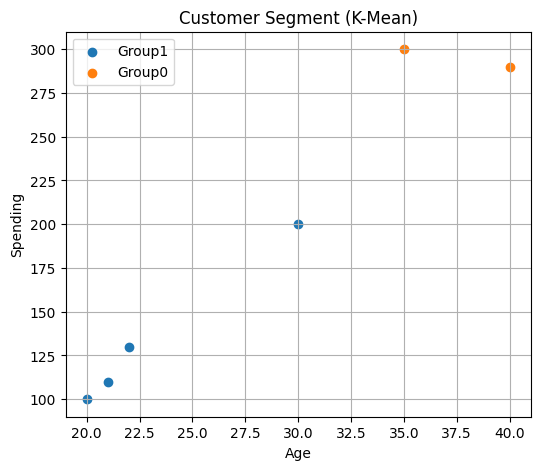

,customer,Age,Spending,group
0,Riya,20,100,1
1,sarvesh,30,200,1
2,Shantanu,35,300,0
3,Shivansh,21,110,1
4,Saurabh,40,290,0


In [11]:
# sample data 
data={
    "customer":["Riya","sarvesh","Shantanu","Shivansh","Saurabh","Sujeet"],
    "Age":[20,30,35,21,40,22],
    "Spending":[100,200,300,110,290,130]
}
df=pd.DataFrame(data)

X =df[["Age","Spending"]] # random state=42 means sets a fixed random seed so the model gives the same output every time.
model=KMeans(n_clusters=2,random_state=42,n_init=10) # n_init=10 means The K-Means algorithm will run 10 times with different initial centroids and choose the best result.
df["group"]=model.fit_predict(X)

plt.figure(figsize=(6, 5))

for group in df["group"].unique():
    group_data=df[df['group']==group]
    plt.scatter(group_data["Age"],group_data["Spending"],label=f'Group{group}')

plt.xlabel("Age")
plt.ylabel("Spending")
plt.title("Customer Segment (K-Mean)")
plt.legend()
plt.grid(True)
plt.show()

df.head()

### Principle Component Analysis.


In [12]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [13]:
data= {
    "Age":[25,30,35,40,45,50],
    "Spending":[70,60,50,40,30,20],
    "Income":[30000,40000,50000,60000,70000,80000],
    'Saving':[1000,5000,8000,10000,150000,20000]
}

df=pd.DataFrame(data)
df.head()


,Age,Spending,Income,Saving
0,25,70,30000,1000
1,30,60,40000,5000
2,35,50,50000,8000
3,40,40,60000,10000
4,45,30,70000,150000


Variance captured by PCA component:
[82.8 17.2]


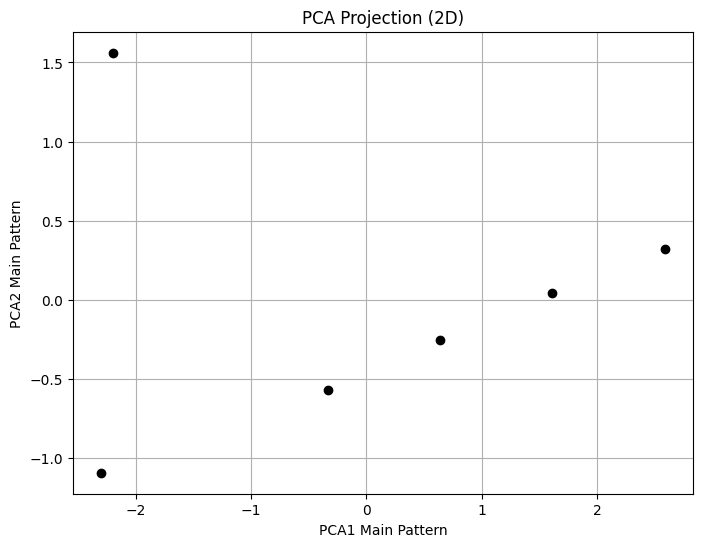

New data with 2 features:
       PCA1      PCA2
0  2.584042  0.318705
1  1.606002  0.039926
2  0.634475 -0.256583
3 -0.330539 -0.570822
4 -2.194334  1.561694
5 -2.299645 -1.092920


In [14]:
scaler=StandardScaler()

scaled_data=scaler.fit_transform(df)
pca=PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(pca_result,columns=['PCA1','PCA2'])

explained_variance = pca.explained_variance_ratio_

print("Variance captured by PCA component:")
print(np.round(explained_variance * 100,2))

plt.figure(figsize=[8,6])

plt.scatter(pca_df['PCA1'],pca_df['PCA2'],color="black")
plt.title("PCA Projection (2D)")
plt.xlabel("PCA1 Main Pattern")
plt.ylabel("PCA2 Main Pattern")
plt.grid(True)
plt.show()

print("New data with 2 features:")
print(pca_df)